# Notebook 05: Sales Forecasting with Prophet
Uses Meta's Prophet library to forecast monthly sales for the next 90 days with confidence intervals.
Business question: "What will Q1 2018 revenue look like based on historical patterns?"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
import os

os.makedirs("../outputs/figures", exist_ok=True)

# Load monthly sales data prepared in notebook 04
df = pd.read_csv("../data/processed/monthly_sales.csv")
df["ds"] = pd.to_datetime(df["ds"])

print("Shape:", df.shape)
print("\nDate range:", df["ds"].min(), "to", df["ds"].max())
print("\nSales stats:")
print(df["y"].describe().round(2))
df.tail(6)

Importing plotly failed. Interactive plots will not work.


Shape: (48, 2)

Date range: 2014-01-01 00:00:00 to 2017-12-01 00:00:00

Sales stats:
count        48.00
mean      47858.35
std       25195.89
min        4519.89
25%       29790.10
50%       39803.25
75%       65833.34
max      118447.82
Name: y, dtype: float64


,ds,y
42,2017-07-01,45264.4160
43,2017-08-01,63120.8880
44,2017-09-01,87866.6520
45,2017-10-01,77776.9232
46,2017-11-01,118447.8250
47,2017-12-01,83829.3188


In [2]:
# Initialise and fit Prophet model
# yearly_seasonality=True captures the annual pattern we saw in decomposition
# weekly_seasonality=False because we have monthly data, not daily
# daily_seasonality=False for same reason

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.90  # 90% confidence interval
)

model.fit(df)
print("Model fitted successfully.")

00:59:29 - cmdstanpy - INFO - Chain [1] start processing
00:59:30 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully.


In [3]:
# Create future dataframe — forecast 3 months ahead (Q1 2018: Jan, Feb, Mar)
future = model.make_future_dataframe(periods=3, freq="MS")

print("Future dataframe tail:")
print(future.tail(6))

Future dataframe tail:
           ds
45 2017-10-01
46 2017-11-01
47 2017-12-01
48 2018-01-01
49 2018-02-01
50 2018-03-01


In [4]:
# Generate forecast
forecast = model.predict(future)

# Key columns: ds, yhat (forecast), yhat_lower, yhat_upper (confidence bounds)
forecast_output = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
forecast_output.columns = ["Date", "Forecast", "Lower_90", "Upper_90"]

print("Forecast for Q1 2018:")
q1_2018 = forecast_output[forecast_output["Date"] >= "2018-01-01"]
print(q1_2018.to_string(index=False))

print(f"\nQ1 2018 Total Forecast: ${q1_2018['Forecast'].sum():,.0f}")
print(f"Q1 2018 Lower bound:    ${q1_2018['Lower_90'].sum():,.0f}")
print(f"Q1 2018 Upper bound:    ${q1_2018['Upper_90'].sum():,.0f}")

Forecast for Q1 2018:
      Date     Forecast     Lower_90     Upper_90
2018-01-01 45772.770284 34731.761454 56680.381406
2018-02-01 32975.255104 22176.040799 43899.271664
2018-03-01 72181.347653 61600.873935 83994.967132

Q1 2018 Total Forecast: $150,929
Q1 2018 Lower bound:    $118,509
Q1 2018 Upper bound:    $184,575


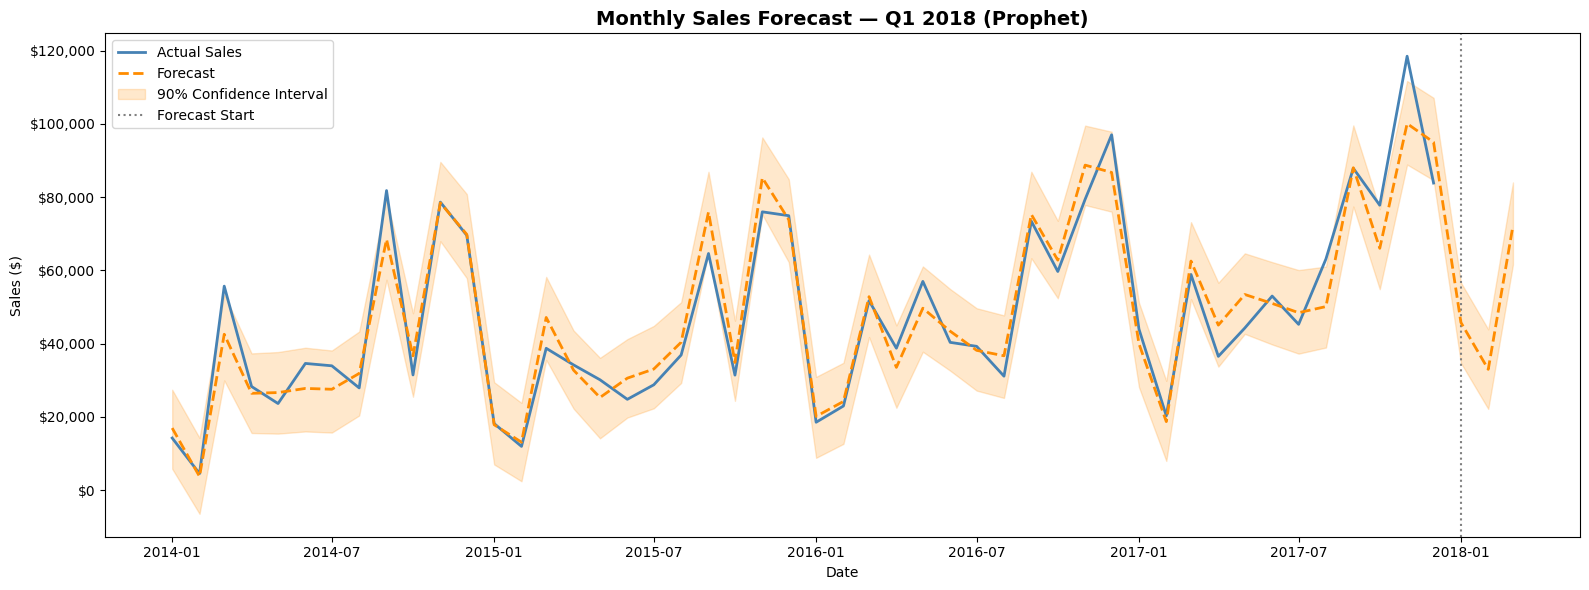

Saved.


In [5]:
# Plot forecast with confidence intervals
fig, ax = plt.subplots(figsize=(16, 6))

# Historical data
ax.plot(df["ds"], df["y"], color="steelblue", linewidth=2, label="Actual Sales", zorder=3)

# Forecast line
ax.plot(forecast_output["Date"], forecast_output["Forecast"],
        color="darkorange", linewidth=2, linestyle="--", label="Forecast", zorder=3)

# Confidence interval
ax.fill_between(forecast_output["Date"],
                forecast_output["Lower_90"],
                forecast_output["Upper_90"],
                alpha=0.2, color="darkorange", label="90% Confidence Interval")

# Vertical line marking forecast start
ax.axvline(pd.Timestamp("2018-01-01"), color="gray", linestyle=":", linewidth=1.5, label="Forecast Start")

ax.set_title("Monthly Sales Forecast — Q1 2018 (Prophet)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/sales_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

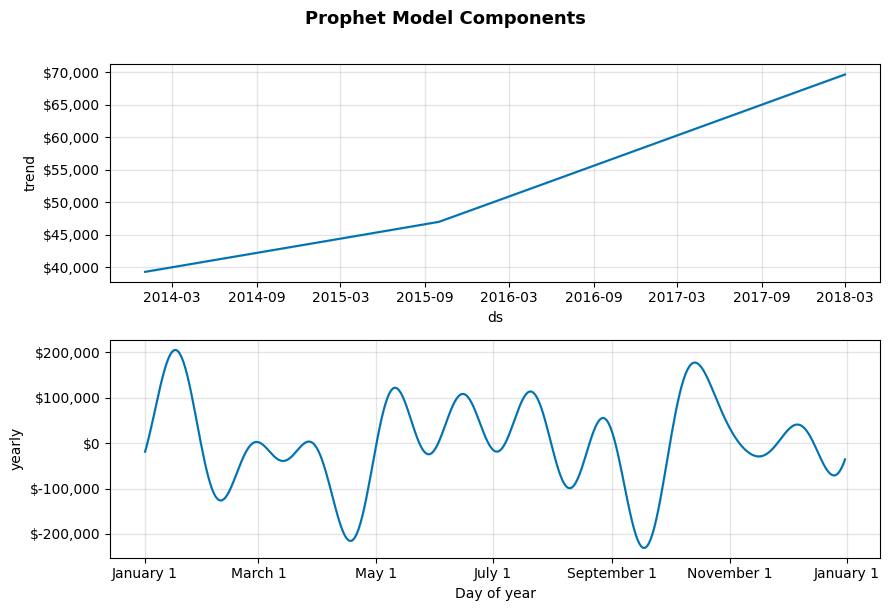

Saved.


In [6]:
# Plot Prophet components — trend and seasonality separately
fig = model.plot_components(forecast)
axes = fig.get_axes()

# Format y-axis on all subplots
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

fig.suptitle("Prophet Model Components", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/prophet_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [7]:
# Model accuracy — backtest on last 6 months of known data
# Compare Prophet's in-sample predictions vs actual values

actuals = df.copy()
predicted = forecast_output[forecast_output["Date"].isin(actuals["ds"])].copy()
predicted = predicted.rename(columns={"Date": "ds", "Forecast": "yhat"})

merged = actuals.merge(predicted[["ds", "yhat"]], on="ds")
merged["error"] = merged["y"] - merged["yhat"]
merged["abs_pct_error"] = (abs(merged["error"]) / merged["y"]) * 100

last6 = merged.tail(6)
print("Last 6 months — Actual vs Forecast:")
print(last6[["ds", "y", "yhat", "abs_pct_error"]].to_string(index=False))
print(f"\nMean Absolute Percentage Error (last 6 months): {last6['abs_pct_error'].mean():.1f}%")
print(f"Overall MAPE (all months): {merged['abs_pct_error'].mean():.1f}%")

Last 6 months — Actual vs Forecast:
        ds           y          yhat  abs_pct_error
2017-07-01  45264.4160  48443.199788       7.022699
2017-08-01  63120.8880  50114.707142      20.605193
2017-09-01  87866.6520  88000.205987       0.151996
2017-10-01  77776.9232  66019.910431      15.116325
2017-11-01 118447.8250 100051.690142      15.531003
2017-12-01  83829.3188  94971.170612      13.291116

Mean Absolute Percentage Error (last 6 months): 12.0%
Overall MAPE (all months): 11.5%


In [8]:
# Quarterly comparison — actual Q4 vs forecasted Q1 2018
actual_q4_2017 = df[df["ds"] >= "2017-10-01"]["y"].sum()
forecast_q1_2018 = q1_2018["Forecast"].sum()
forecast_q1_lower = q1_2018["Lower_90"].sum()
forecast_q1_upper = q1_2018["Upper_90"].sum()

print("=== QUARTERLY REVENUE SUMMARY ===")
print(f"\nActual Q4 2017:          ${actual_q4_2017:,.0f}")
print(f"\nForecast Q1 2018:        ${forecast_q1_2018:,.0f}")
print(f"  Lower bound (90% CI):  ${forecast_q1_lower:,.0f}")
print(f"  Upper bound (90% CI):  ${forecast_q1_upper:,.0f}")
print(f"\nExpected Q1 vs Q4 change: {((forecast_q1_2018 - actual_q4_2017) / actual_q4_2017) * 100:+.1f}%")
print("\nNote: Q1 is historically the weakest quarter — Jan/Feb show strong negative")
print("seasonal effects as seen in decomposition. This drop is expected and normal.")

=== QUARTERLY REVENUE SUMMARY ===

Actual Q4 2017:          $280,054

Forecast Q1 2018:        $150,929
  Lower bound (90% CI):  $118,509
  Upper bound (90% CI):  $184,575

Expected Q1 vs Q4 change: -46.1%

Note: Q1 is historically the weakest quarter — Jan/Feb show strong negative
seasonal effects as seen in decomposition. This drop is expected and normal.


In [9]:
# Save forecast output to CSV
forecast_output.to_csv("../data/processed/forecast_output.csv", index=False)
print("forecast_output.csv saved to data/processed/")
print("\nFull forecast shape:", forecast_output.shape)
forecast_output.tail(6)

forecast_output.csv saved to data/processed/

Full forecast shape: (51, 4)


,Date,Forecast,Lower_90,Upper_90
45,2017-10-01,66019.910431,54851.216146,76711.074250
46,2017-11-01,100051.690142,88876.533762,111682.970019
47,2017-12-01,94971.170612,84595.255389,107089.806418
48,2018-01-01,45772.770284,34731.761454,56680.381406
49,2018-02-01,32975.255104,22176.040799,43899.271664
50,2018-03-01,72181.347653,61600.873935,83994.967132
